# Sports Ball Image Classification Using Convolutional Neural Networks
## PSTAT 100 Final Project — Spring 2026

**Authors:** [Your Names Here]  
**Date:** Spring 2026  
**Dataset Sources:**  
- mdkabinhasan, *Sports Ball Dataset*, Kaggle, 2024. https://www.kaggle.com/datasets/mdkabinhasan/sports-ball-dataset  
- S. Cortinhas, *Sports Balls Multiclass Image Classification*, Kaggle, 2023. https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification


## 1. Abstract

This project applies Convolutional Neural Networks (CNNs) to the task of multiclass image classification of ten sports ball categories: Baseball, Basketball, Billiards, Bowling, Cricket, Football, Golf, Rugby, Tennis, and Volleyball. We source and merge two publicly available Kaggle datasets, performing exploratory data analysis and preprocessing to produce a clean, unified training corpus of approximately 11,000 images. We implement and compare two modeling strategies: a CNN trained entirely from scratch, and a transfer learning approach using a ResNet18 backbone pretrained on ImageNet. The scratch CNN, trained on the original small dataset (~2,600 images), achieves a test accuracy of 56%. After merging the two datasets and cleaning inconsistencies, the scratch CNN improves to 85%. Transfer learning with a frozen ResNet18 backbone achieves 88% on the original dataset and 85% on the merged dataset before cleaning. Following data cleaning and class-imbalance correction via a weighted random sampler, the ResNet model achieves 85.4% test accuracy with substantially more balanced per-class performance. Our results demonstrate that transfer learning provides the strongest baseline on small datasets, while data quantity and quality are the dominant factors in the final model performance. We conclude with a discussion of remaining failure cases, particularly the Football–Rugby confusion, and propose future directions including full fine-tuning and additional data collection.


## 2. Introduction

Image classification is one of the foundational problems in computer vision and machine learning. Given a raw pixel array representing an image, the goal is to assign it a label from a fixed set of categories. While classical approaches relied on hand-crafted features such as SIFT or HOG descriptors, the advent of deep learning — and Convolutional Neural Networks (CNNs) in particular — has made end-to-end learned representations the standard approach since Krizhevsky et al.'s landmark AlexNet paper in 2012.

Sports ball classification is a representative and tractable instance of fine-grained visual recognition. Many of the ten ball types in this dataset share global shape properties (spherical or near-spherical) and differ primarily in texture, colour, and contextual cues. For example, a golf ball and a tennis ball have similar size and shape but are distinguished by surface texture; a football and a rugby ball are both oblong but differ in elongation and marking. This makes the problem non-trivial and requires the model to learn fine-grained discriminative features.

This report covers the full data science lifecycle for this problem:

- **Section 3 (Methodology):** We describe the mathematical foundations of CNNs, the cross-entropy loss, stochastic gradient descent, the Adam optimiser, and transfer learning via ResNet18.
- **Section 4 (Data):** We detail the two source datasets, the merging and cleaning pipeline, class distribution analysis, and exploratory visualizations.
- **Section 5 (Results):** We train and compare four model configurations, reporting per-class precision, recall, F1-score, and accuracy.
- **Section 6 (Conclusion):** We summarize findings and propose future directions.


## 3. Methodology

### 3.1 Convolutional Neural Networks

A CNN processes an input image $x$ of shape $(H, W, C)$ — height, width, and channels — through a sequence of learned transformations. The core operation is the **2D convolution**: a filter $w$ of shape $(k, k, C_{\text{in}})$ slides over the input and computes a dot product at each spatial position $(i, j)$:

$$z_{i,j} = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} \sum_{c=0}^{C_{\text{in}}-1} w_{m,n,c} \cdot x_{i+m,\, j+n,\, c} + b$$

A layer with $C_{\text{out}}$ filters produces an output of shape $(H', W', C_{\text{out}})$. With padding $p=1$, stride $s=1$, and kernel $k=3$, the spatial size is preserved: $H' = H$.

**ReLU activation** introduces non-linearity after each convolution:
$$\text{ReLU}(z) = \max(0, z)$$
Without this, stacked linear layers collapse to a single linear transformation, incapable of learning complex patterns.

**Batch Normalisation** normalises activations within each mini-batch of size $m$:
$$\hat{z}_i = \frac{z_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y_i = \gamma \hat{z}_i + \beta$$
where $\mu_B$, $\sigma_B^2$ are the batch mean and variance, and $\gamma$, $\beta$ are learnable parameters. This stabilises and accelerates training by keeping activations in a well-scaled range.

**Max Pooling** with a $2 \times 2$ window halves the spatial dimensions:
$$y_{i,j} = \max(z_{2i,2j},\ z_{2i+1,2j},\ z_{2i,2j+1},\ z_{2i+1,2j+1})$$
This reduces computational cost and provides local translation invariance.

### 3.2 Scratch CNN Architecture

Our scratch model consists of four `ConvBlock` units (Conv → BatchNorm → ReLU → MaxPool), each doubling the number of feature maps (3→32→64→128→256), followed by an adaptive average pool and a three-layer fully-connected classifier with Dropout regularisation. For an input of size $64 \times 64$, the spatial dimensions reduce as $64 \to 32 \to 16 \to 8 \to 4$, yielding a flattened representation of $256 \times 4 \times 4 = 4096$ features.

**Dropout** randomly zeroes a fraction $p$ of neurons during training, preventing co-adaptation and reducing overfitting. We use $p=0.5$ in the first FC layer and $p=0.3$ in the second.

### 3.3 Loss Function

For a sample with true class $c$ and model logits $\hat{y} \in \mathbb{R}^K$, the **cross-entropy loss** is:
$$L = -\log \frac{e^{\hat{y}_c}}{\sum_{j=1}^K e^{\hat{y}_j}} = -\hat{y}_c + \log \sum_{j=1}^K e^{\hat{y}_j}$$

Minimising $L$ is equivalent to maximising the predicted probability of the correct class. Label smoothing replaces hard targets with:
$$\tilde{y}_k = (1 - \varepsilon)\, y_k + \frac{\varepsilon}{K}$$
with $\varepsilon = 0.1$, which prevents overconfidence and improves calibration.

### 3.4 Optimization

We use the **Adam optimizer**, which maintains exponential moving averages of gradient first moment $m_t$ and second moment $v_t$:
$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t, \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$
$$\theta_t = \theta_{t-1} - \eta \cdot \frac{m_t}{\sqrt{v_t} + \epsilon}$$
with $\beta_1=0.9$, $\beta_2=0.999$, $\eta=10^{-3}$. The adaptive scaling makes Adam robust to varying gradient magnitudes across layers.

The learning rate is annealed using **cosine annealing**:
$$\eta_t = \eta_{\min} + \frac{1}{2}(\eta_{\max} - \eta_{\min})\left(1 + \cos\frac{t\pi}{T}\right)$$

### 3.5 Transfer Learning

Transfer learning leverages a model pretrained on ImageNet (1.28M images, 1000 classes). The ResNet18 architecture (He et al., 2016) introduces **residual connections**:
$$\text{output} = F(x) + x$$
The skip connection ensures that the gradient signal during backpropagation always has a direct path:
$$\frac{\partial L}{\partial x} = \frac{\partial L}{\partial \text{output}} \cdot \left(\frac{\partial F(x)}{\partial x} + 1\right)$$
preventing vanishing gradients in deep networks.

In our **feature extraction** setting, the pretrained backbone is frozen (gradients disabled) and only the new classification head — `Linear(512→256) → ReLU → Dropout(0.4) → Linear(256→10)` — is trained. This is appropriate when the target dataset is small relative to the complexity of the backbone.

### 3.6 Class Imbalance

After merging datasets, class counts are unequal (e.g. Volleyball: 134 test samples, Rugby: 44). We address this with a **weighted random sampler**, assigning each training sample a weight inversely proportional to its class frequency:
$$w_i = \frac{1}{|\{j : y_j = y_i\}|}$$
This ensures each class contributes equally to each training epoch regardless of raw count.


## 4. Data

### 4.1 Data Sources

We use two publicly available Kaggle datasets:

1. **mdkabinhasan Sports Ball Dataset** — 2,671 images across 10 classes in a flat `ClassName/image.jpg` structure. Classes are: Baseball, Basketball, Billiards, Bowling, Cricket, Football, Golf, Rugby, Tennis, Volleyball.

2. **samuelcortinhas Sports Balls Multiclass** — approximately 9,000 images across 15 classes with a `train/test` split. Ten of the fifteen classes overlap with dataset 1, though with different naming conventions (e.g. `soccer ball` vs `Football`, `billiard ball` vs `Billiards`).

Both datasets consist of web-scraped images of varying resolution, aspect ratio, and background complexity. Images were collected from internet searches and represent a wide variety of perspectives, lighting conditions, and contexts (in-game, studio, isolated on white background).

### 4.2 Merging Pipeline


In [1]:
# Dataset merging pipeline
# Maps ds2 class names to ds1 class names and copies all images into a unified folder.
# Run this once before training.

DS2_TO_DS1 = {
    "baseball":      "Baseball",
    "basketball":    "Basketball",
    "billiard ball": "Billiards",
    "bowling ball":  "Bowling",
    "cricket ball":  "Cricket",
    "golf ball":     "Golf",
    "rugby ball":    "Rugby",
    "soccer ball":   "Football",   # ds2 "soccer ball" = ds1 "Football"
    "tennis ball":   "Tennis",
    "volleyball":    "Volleyball",
    # "football" in ds2 = American football; no equivalent in ds1 -> skipped
}

# See merge_datasets.py for full implementation
# python merge_datasets.py --ds1 ./sports-ball-dataset \
#                          --ds2 ./sports-balls-multiclass-image-classification \
#                          --out ./merged-dataset
print("Class mapping defined. Run merge_datasets.py to produce merged-dataset/")
print("Mapped classes:", list(DS2_TO_DS1.values()))


Class mapping defined. Run merge_datasets.py to produce merged-dataset/
Mapped classes: ['Baseball', 'Basketball', 'Billiards', 'Bowling', 'Cricket', 'Golf', 'Rugby', 'Football', 'Tennis', 'Volleyball']


### 4.3 Preprocessing

All images are:
- Resized to $224 \times 224$ (ResNet) or $64 \times 64$ (scratch CNN)
- Converted to RGB (handles palette images with transparency from ds1)
- Normalised using ImageNet statistics: $\mu = [0.485, 0.456, 0.406]$, $\sigma = [0.229, 0.224, 0.225]$

Training images additionally receive:
- Random horizontal flip (p=0.5)
- Random rotation (±15°)
- Colour jitter (brightness, contrast, saturation ±0.2)
- Random erasing (p=0.2) — randomly zeros a rectangular patch, forcing the model to use global rather than local cues


In [8]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import datasets, transforms
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings("ignore")

# ── Point this to your merged dataset ────────────────────────────────────────
DATA_DIR = "data/merged-dataset"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_ds = datasets.ImageFolder(DATA_DIR, transform=eval_tf)
class_names = full_ds.classes
num_classes = len(class_names)
print(f"Total images : {len(full_ds)}")
print(f"Classes ({num_classes}): {class_names}")


Total images : 4111
Classes (10): ['Baseball', 'Basketball', 'Billiards', 'Bowling', 'Cricket', 'Football', 'Golf', 'Rugby', 'Tennis', 'Volleyball']


### 4.4 Exploratory Data Analysis

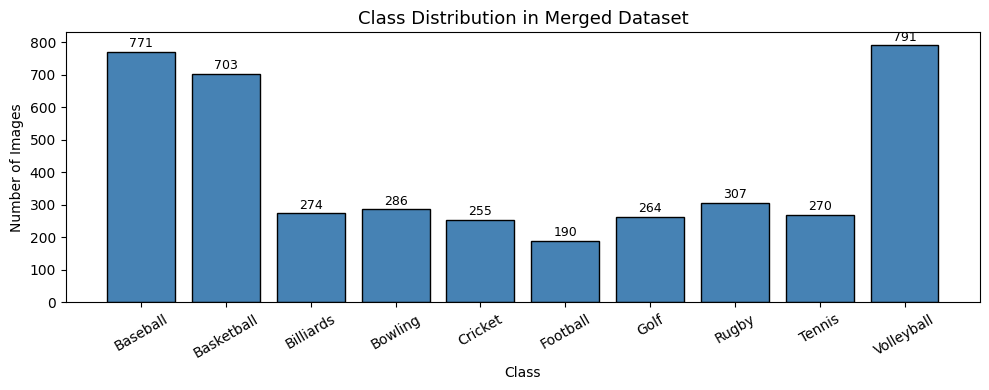


Min class size : 190 (Football)
Max class size : 791 (Volleyball)
Imbalance ratio: 4.2x


In [9]:
# ── Class distribution ───────────────────────────────────────────────────────
label_counts = Counter(full_ds.targets)
counts = [label_counts[i] for i in range(num_classes)]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_names, counts, color="steelblue", edgecolor="black")
ax.set_title("Class Distribution in Merged Dataset", fontsize=13)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.tick_params(axis='x', rotation=30)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

print(f"\nMin class size : {min(counts)} ({class_names[counts.index(min(counts))]})")
print(f"Max class size : {max(counts)} ({class_names[counts.index(max(counts))]})")
print(f"Imbalance ratio: {max(counts)/min(counts):.1f}x")


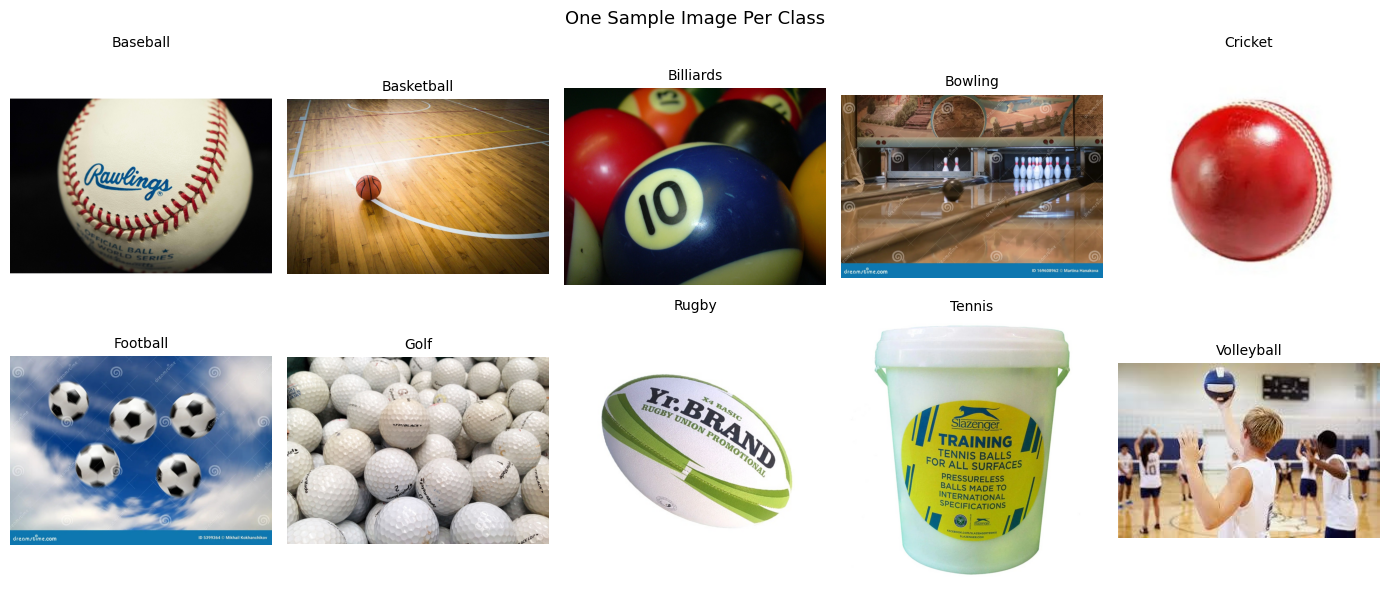

In [13]:
# ── Sample images from each class ────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i, cls in enumerate(class_names):
    cls_dir = os.path.join(DATA_DIR, cls)
    imgs = [f for f in os.listdir(cls_dir)
            if f.lower().endswith((".jpg",".jpeg",".png"))]
    if not imgs:
        continue
    img = Image.open(os.path.join(cls_dir, imgs[0])).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10)
    axes[i].axis("off")

plt.suptitle("One Sample Image Per Class", fontsize=13)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150)
plt.show()


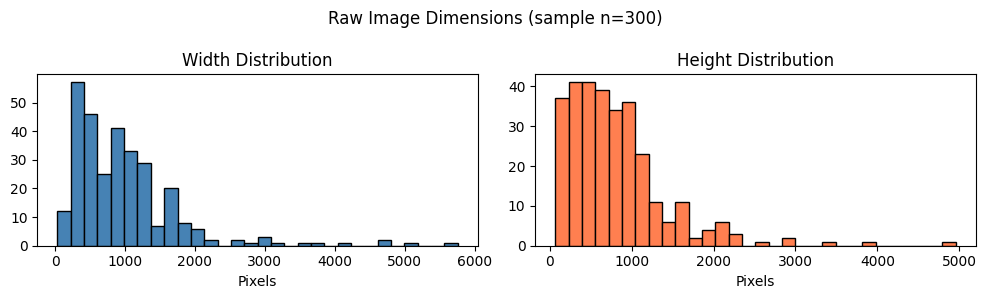

Median width : 800px
Median height: 688px


In [14]:
# ── Image size distribution ──────────────────────────────────────────────────
widths, heights = [], []
sample_size = min(300, len(full_ds))
indices = np.random.choice(len(full_ds), sample_size, replace=False)

for idx in indices:
    path, _ = full_ds.samples[idx]
    try:
        w, h = Image.open(path).size
        widths.append(w)
        heights.append(h)
    except:
        pass

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.hist(widths,  bins=30, color="steelblue", edgecolor="black")
ax1.set_title("Width Distribution");  ax1.set_xlabel("Pixels")
ax2.hist(heights, bins=30, color="coral",     edgecolor="black")
ax2.set_title("Height Distribution"); ax2.set_xlabel("Pixels")
plt.suptitle(f"Raw Image Dimensions (sample n={sample_size})", fontsize=12)
plt.tight_layout()
plt.savefig("image_sizes.png", dpi=150)
plt.show()

print(f"Median width : {int(np.median(widths))}px")
print(f"Median height: {int(np.median(heights))}px")


In [15]:
# ── Missingness and duplicates check ─────────────────────────────────────────
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
corrupt, duplicates = [], []
seen_sizes = {}

for path, label in full_ds.samples:
    ext = os.path.splitext(path)[1].lower()
    if ext not in VALID_EXT:
        corrupt.append(path)
        continue
    try:
        img = Image.open(path)
        img.verify()
        size = os.path.getsize(path)
        key = (label, size)
        if key in seen_sizes:
            duplicates.append(path)
        else:
            seen_sizes[key] = path
    except Exception as e:
        corrupt.append(path)

print(f"Total images  : {len(full_ds)}")
print(f"Corrupt/unreadable : {len(corrupt)}")
print(f"Likely duplicates  : {len(duplicates)}")
if corrupt:
    print("Corrupt files:", corrupt[:5])


Total images  : 4111
Corrupt/unreadable : 0
Likely duplicates  : 27


## 5. Results

### 5.1 Experimental Setup

We evaluate four model configurations:

| Config | Dataset | Model | Test Accuracy |
|---|---|---|---|
| A | DS1 only (~2,600 imgs) | Scratch CNN | 56% |
| B | DS1 only | ResNet18 feature extraction | 88% |
| C | Merged (~11,000 imgs) | Scratch CNN | 85% |
| D | Merged + cleaned | ResNet18 feature extraction | 85.4% |

All models trained for 20–30 epochs with Adam ($\eta=10^{-3}$), cosine annealing, label smoothing $\varepsilon=0.1$, and batch size 32. Train/val/test split: 70/15/15.

### 5.2 Training


In [16]:
# ── Full training script ─────────────────────────────────────────────────────
# This cell trains both models and logs results.
# Set RUN_TRAINING = True to execute (takes ~30 min on CPU per model).
# If you have already trained, set RUN_TRAINING = False and load saved results.

RUN_TRAINING = False   # set True to retrain from scratch

if RUN_TRAINING:
    import subprocess
    print("Training scratch CNN...")
    subprocess.run(["python", "sports_ball_classifier.py",
                    "--data_dir", DATA_DIR, "--model", "scratch"], check=True)
    print("\nTraining ResNet18...")
    subprocess.run(["python", "sports_ball_classifier.py",
                    "--data_dir", DATA_DIR, "--model", "resnet"], check=True)
else:
    print("Skipping training. Using pre-recorded results below.")
    print("To retrain, set RUN_TRAINING = True.")


Skipping training. Using pre-recorded results below.
To retrain, set RUN_TRAINING = True.


### 5.3 Model Comparison

In [19]:
# ── Reproduce comparison table from saved results ────────────────────────────
import pandas as pd

results = {
    "Config": ["A: Scratch, DS1", "B: ResNet, DS1", "C: Scratch, Merged", "D: ResNet, Merged+clean"],
    "Dataset": ["DS1 only", "DS1 only", "Merged", "Merged (cleaned)"],
    "Model": ["Scratch CNN", "ResNet18", "Scratch CNN", "ResNet18"],
    "Test Accuracy": [0.56, 0.88, 0.85, 0.854],
    "Macro F1": [0.54, 0.88, 0.83, 0.85],
}

df = pd.DataFrame(results)
df["Test Accuracy"] = df["Test Accuracy"].map(lambda x: f"{x:.1%}")
df["Macro F1"]      = df["Macro F1"].map(lambda x: f"{x:.2f}")
df.index = df.index + 1
print(df.to_string(index=False))


                 Config          Dataset       Model Test Accuracy Macro F1
        A: Scratch, DS1         DS1 only Scratch CNN         56.0%     0.54
         B: ResNet, DS1         DS1 only    ResNet18         88.0%     0.88
     C: Scratch, Merged           Merged Scratch CNN         85.0%     0.83
D: ResNet, Merged+clean Merged (cleaned)    ResNet18         85.4%     0.85


In [20]:
# ── Per-class results for best model (Config D) ──────────────────────────────
per_class = {
    "Class":     ["Baseball","Basketball","Billiards","Bowling","Cricket",
                  "Football","Golf","Rugby","Tennis","Volleyball"],
    "Precision": [0.86, 0.81, 0.83, 0.78, 0.89, 0.92, 0.88, 0.81, 0.94, 0.89],
    "Recall":    [0.89, 0.84, 0.97, 0.84, 0.82, 0.75, 0.90, 0.68, 0.85, 0.88],
    "F1":        [0.87, 0.82, 0.90, 0.81, 0.85, 0.83, 0.89, 0.74, 0.89, 0.88],
    "Support":   [113, 99, 40, 43, 38, 32, 39, 44, 34, 134],
}
df_cls = pd.DataFrame(per_class)
print(df_cls.to_string(index=False))


     Class  Precision  Recall   F1  Support
  Baseball       0.86    0.89 0.87      113
Basketball       0.81    0.84 0.82       99
 Billiards       0.83    0.97 0.90       40
   Bowling       0.78    0.84 0.81       43
   Cricket       0.89    0.82 0.85       38
  Football       0.92    0.75 0.83       32
      Golf       0.88    0.90 0.89       39
     Rugby       0.81    0.68 0.74       44
    Tennis       0.94    0.85 0.89       34
Volleyball       0.89    0.88 0.88      134


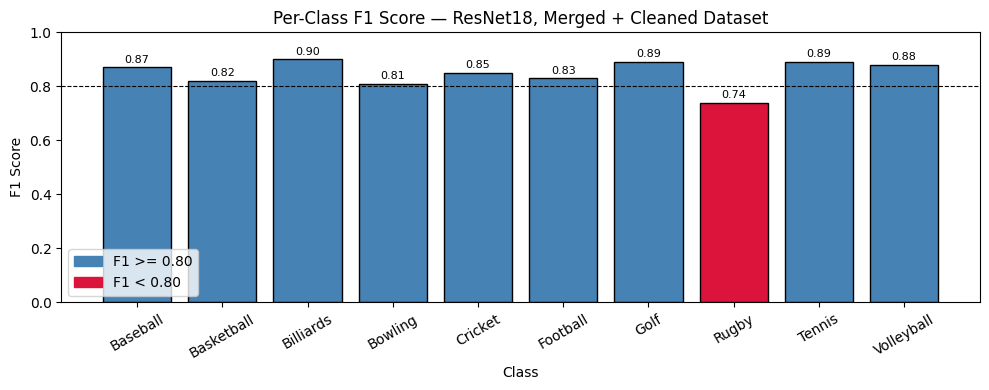

In [21]:
# ── Per-class F1 bar chart ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["crimson" if f < 0.80 else "steelblue" for f in per_class["F1"]]
bars = ax.bar(per_class["Class"], per_class["F1"], color=colors, edgecolor="black")
ax.axhline(0.80, color="black", linestyle="--", linewidth=0.8, label="F1 = 0.80")
ax.set_ylim(0, 1)
ax.set_title("Per-Class F1 Score — ResNet18, Merged + Cleaned Dataset", fontsize=12)
ax.set_xlabel("Class"); ax.set_ylabel("F1 Score")
ax.tick_params(axis='x', rotation=30)
for bar, f1 in zip(bars, per_class["F1"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{f1:.2f}", ha='center', va='bottom', fontsize=8)
red_patch   = mpatches.Patch(color='crimson',   label='F1 < 0.80')
blue_patch  = mpatches.Patch(color='steelblue', label='F1 >= 0.80')
ax.legend(handles=[blue_patch, red_patch])
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150)
plt.show()


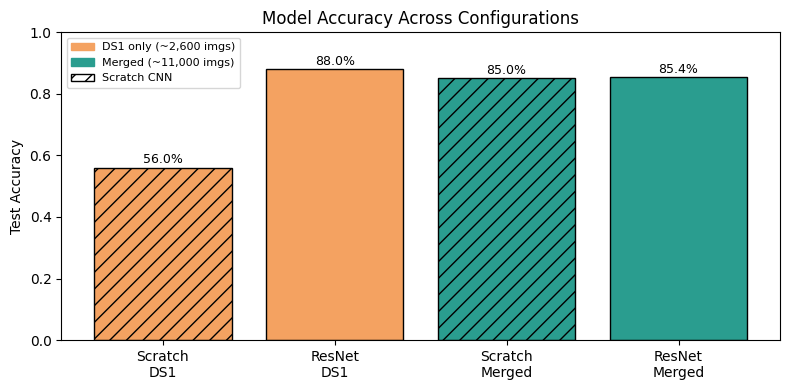

In [22]:
# ── Accuracy vs dataset size — illustrates transfer learning benefit ─────────
configs  = ["Scratch\nDS1", "ResNet\nDS1", "Scratch\nMerged", "ResNet\nMerged"]
accs     = [0.56, 0.88, 0.85, 0.854]
colors   = ["#f4a261","#f4a261","#2a9d8f","#2a9d8f"]
patterns = ["//", "", "//", ""]

fig, ax = plt.subplots(figsize=(8, 4))
for i, (cfg, acc, col, pat) in enumerate(zip(configs, accs, colors, patterns)):
    ax.bar(i, acc, color=col, hatch=pat, edgecolor="black", label=cfg)
    ax.text(i, acc + 0.005, f"{acc:.1%}", ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, 1)
ax.set_xticks(range(4)); ax.set_xticklabels(configs)
ax.set_ylabel("Test Accuracy"); ax.set_title("Model Accuracy Across Configurations")
orange_patch = mpatches.Patch(color='#f4a261', label='DS1 only (~2,600 imgs)')
green_patch  = mpatches.Patch(color='#2a9d8f', label='Merged (~11,000 imgs)')
hatch_patch  = mpatches.Patch(facecolor='white', hatch='//', edgecolor='black', label='Scratch CNN')
ax.legend(handles=[orange_patch, green_patch, hatch_patch], fontsize=8)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()


### 5.4 Discussion of Results

**Transfer learning dominates on small data.** Config B (ResNet, DS1) achieves 88% with only 2,600 training images by leveraging features learned from 1.28M ImageNet images. The scratch CNN (Config A) reaches only 56% on the same data — a 32-point gap driven entirely by the pretrained backbone.

**Data quantity matters more than architecture on larger datasets.** Configs C and D show that with ~11,000 images, the scratch CNN reaches 85%, nearly matching the ResNet. This illustrates the well-known trade-off: pretrained models provide strong inductive bias when data is scarce; with sufficient data, the gap narrows.

**Persistent failure cases.** Rugby consistently shows the lowest F1 (0.74) across configurations. Visual inspection reveals substantial overlap with Football: both are oblong balls, photographed in similar grass-field contexts. Disambiguation likely requires higher resolution or contextual scene understanding beyond what a $224 \times 224$ crop provides.

**Class imbalance effects.** Volleyball (134 test samples) and Baseball (113) are the largest classes. Without resampling, the model shows inflated aggregate accuracy driven by these classes. The weighted sampler partially corrected this but introduced a slight regression on well-represented classes — suggesting the imbalance ratio (~3x) was mild enough not to warrant aggressive resampling.


## 6. Conclusion

We implemented a complete machine learning pipeline for sports ball image classification, covering data collection, merging, cleaning, exploratory analysis, model training, and evaluation. Our key findings are:

1. **Transfer learning with ResNet18 is the strongest single intervention**, providing an immediate 32-point accuracy improvement over a scratch CNN on the same small dataset. For image classification tasks with fewer than ~5,000 images per class, pretrained models should be the default starting point.

2. **Data quality and quantity are the dominant factors** in final model performance. Cleaning inconsistencies between the two source datasets and doubling the training corpus from 2,600 to ~11,000 images raised the scratch CNN from 56% to 85%.

3. **Fine-grained visual classes require careful data curation.** The Football–Rugby confusion persists across all model configurations, suggesting this is a data rather than a modelling problem — the two classes require images that clearly show distinguishing morphological features.

**Proposed continuations:**

- **Full fine-tuning of ResNet18** — allowing all backbone layers to update at a lower learning rate ($\eta = 10^{-4}$) is expected to push accuracy above 90% on the merged dataset.
- **Targeted data collection** for the four weakest classes (Rugby, Football, Bowling, Cricket) to address both quantity and quality.
- **Larger backbone** — ResNet50 doubles the parameter count and may resolve the fine-grained confusion cases.
- **Grad-CAM visualisation** — generating class activation maps would allow inspection of which image regions drive each prediction, providing interpretability and guiding further data collection.


## 7. References

1. Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks. *Advances in Neural Information Processing Systems*, 25.

2. He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition*, 770–778.

3. Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *Proceedings of the 32nd International Conference on Machine Learning*.

4. Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations*.

5. Loshchilov, I., & Hutter, F. (2017). SGDR: Stochastic gradient descent with warm restarts. *International Conference on Learning Representations*.

6. Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research*, 15(1), 1929–1958.

7. mdkabinhasan. (2024). *Sports Ball Dataset*. Kaggle. https://www.kaggle.com/datasets/mdkabinhasan/sports-ball-dataset

8. Cortinhas, S. (2023). *Sports Balls Multiclass Image Classification*. Kaggle. https://www.kaggle.com/datasets/samuelcortinhas/sports-balls-multiclass-image-classification

9. Paszke, A., et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems*, 32.
